<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°05





**Objetivo**: Explorar y visualizar datos de Netflix usando **matplotlib** y **seaborn/plotly**, aprendiendo a elegir gráficos adecuados para distintos tipos de variables y preguntas de análisis.



**Dataset**:

Trabajaremos con el archivo `netflix_titles.csv`, que contiene información sobre los títulos disponibles en la plataforma Netflix hasta el año 2021.

| Variable       | Clase     | Descripción                                                                 |
|----------------|-----------|------------------------------------------------------------------------------|
| show_id        | caracter  | Identificador único del título en el catálogo de Netflix.                   |
| type           | caracter  | Tipo de contenido: 'Movie' o 'TV Show'.                                     |
| title          | caracter  | Título del contenido.                                                       |
| director       | caracter  | Nombre del director (puede ser nulo).                                       |
| cast           | caracter  | Lista de actores principales (puede ser nulo).                              |
| country        | caracter  | País o países donde se produjo el contenido.                                |
| date_added     | fecha     | Fecha en la que el título fue agregado al catálogo de Netflix.              |
| release_year   | entero    | Año de lanzamiento original del título.                                     |
| rating         | caracter  | Clasificación por edad (por ejemplo: 'PG-13', 'TV-MA').                      |
| duration       | caracter  | Duración del contenido (minutos o número de temporadas para series).        |
| listed_in      | caracter  | Categorías o géneros en los que está clasificado el contenido.              |
| description    | caracter  | Breve sinopsis del contenido.                                               |




In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Parte 1: Exploración visual básica

1. **Distribución de tipos de contenido**

   * Realiza un gráfico de barras mostrando la cantidad de películas vs series (`type`).
   * Pregunta guía: ¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?

2. **Histograma de años de lanzamiento**

   * Muestra cómo se distribuyen los títulos según su `release_year`.
   * Pregunta guía: ¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?

3. **Proporción de clasificaciones por edad (`rating`)**

   * Haz un gráfico circular o de barras.
   * Pregunta guía: ¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?



/tmp/ipykernel_52165/1787852454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='muted')


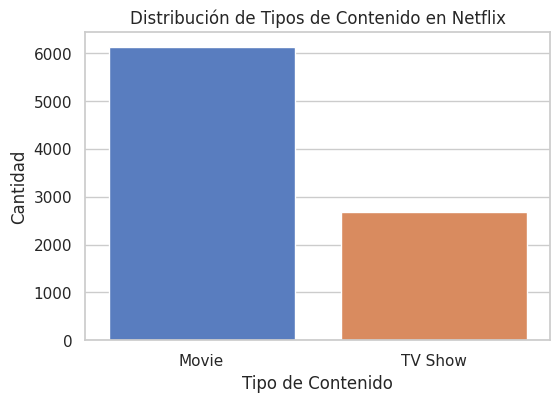

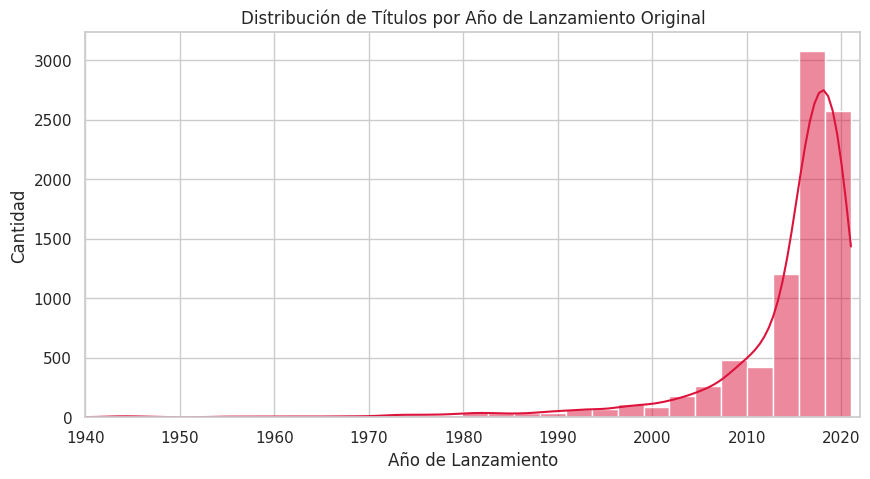

/tmp/ipykernel_52165/1787852454.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=rating_order, palette='viridis')


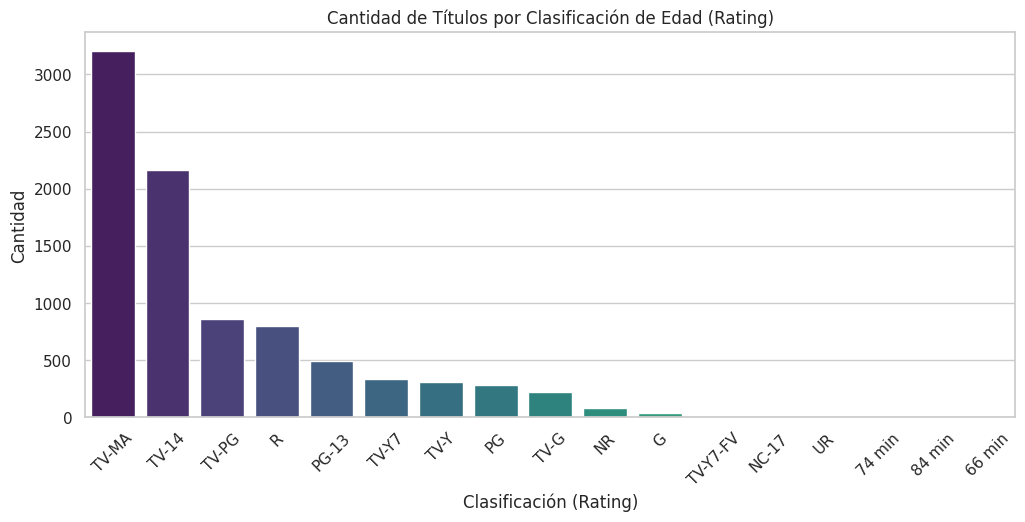

In [3]:
# FIXME
# 1. Distribución de tipos de contenido
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='muted')
plt.title('Distribución de Tipos de Contenido en Netflix')
plt.xlabel('Tipo de Contenido')
plt.ylabel('Cantidad')
plt.show()

# 2. Histograma de años de lanzamiento
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='release_year', bins=35, kde=True, color='crimson')
plt.title('Distribución de Títulos por Año de Lanzamiento Original')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad')
plt.xlim(1940, 2022) # Ajuste para omitir extremos demasiado antiguos y visualizar mejor la tendencia moderna
plt.show()

# 3. Proporción de clasificaciones por edad (rating)
plt.figure(figsize=(12, 5))
rating_order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=rating_order, palette='viridis')
plt.title('Cantidad de Títulos por Clasificación de Edad (Rating)')
plt.xlabel('Clasificación (Rating)')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()



## 🎨 Parte 2: Tendencias y evolución en el tiempo

4. **Número de títulos agregados por año**

   * Usa `date_added` (convertido a fecha) y grafica una serie temporal.
   * Pregunta guía: ¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?

5. **Heatmap de lanzamientos por año y mes**

   * Construye un mapa de calor con `year_added` y `month_added`.
   * Pregunta guía: ¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?

6. **Duración de películas por género**

   * Extrae la duración en minutos y crea un boxplot agrupado por género principal.
   * Pregunta guía: ¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?


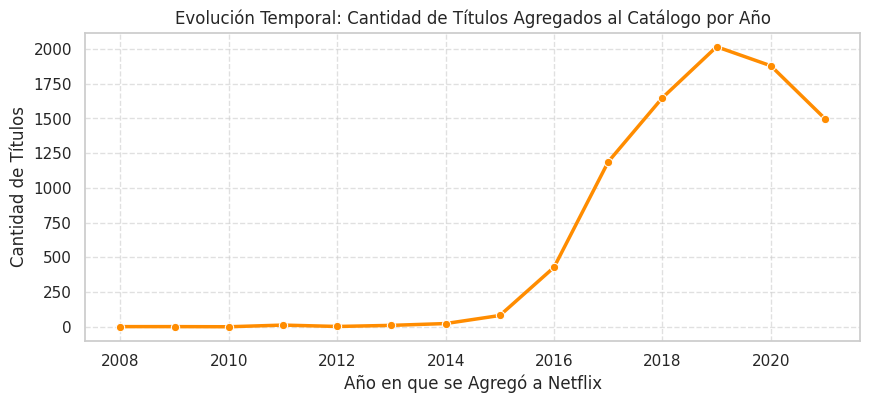

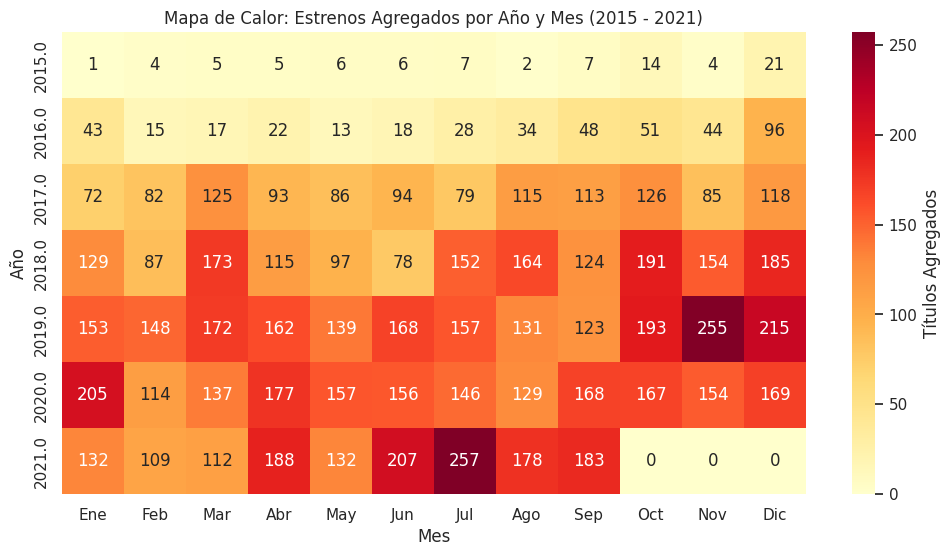

/tmp/ipykernel_52165/3780414239.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered_genres, x='genre', y='duration_min', palette='Set3')


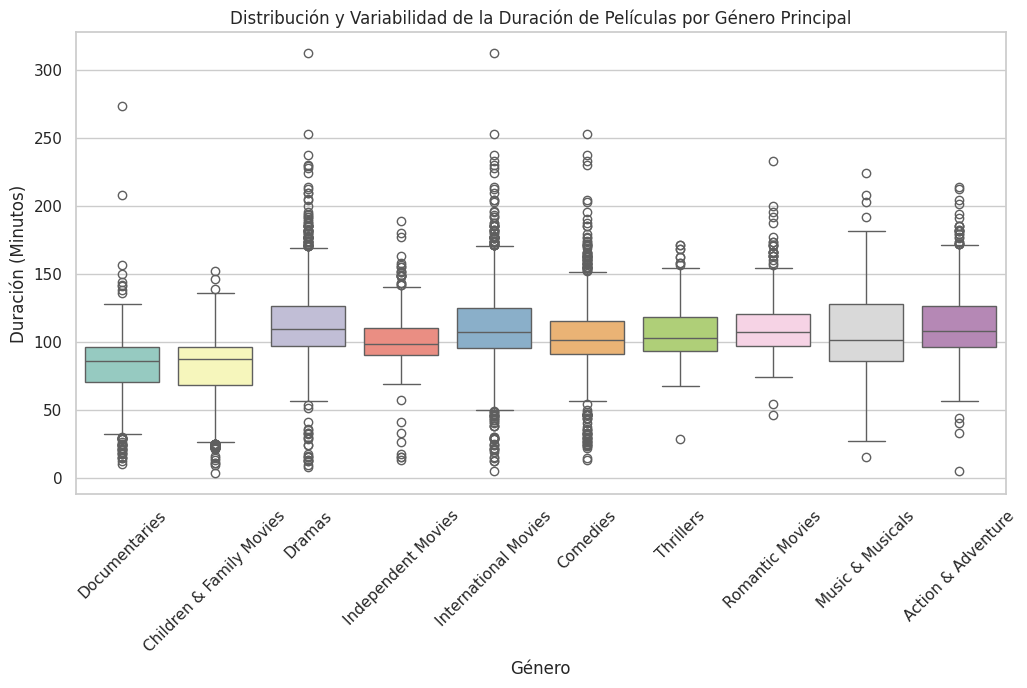

In [4]:
# FIXME
# --- Preparación previa de datos ---
df['date_added_dt'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added_dt'].dt.year
df['month_added'] = df['date_added_dt'].dt.month

# Extraer duración numérica en minutos (solo películas)
df['duration_min'] = df.apply(
    lambda r: float(r['duration'].split()[0]) if pd.notnull(r['duration']) and r['type'] == 'Movie' else None,
    axis=1
)

# Explotar géneros para asociar duración a géneros principales individuales
df_exploded_genres = df.copy()
df_exploded_genres['genre'] = df_exploded_genres['listed_in'].str.split(', ')
df_exploded_genres = df_exploded_genres.explode('genre')


# 4. Número de títulos agregados por año (Serie Temporal)
titulos_por_anio = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.lineplot(x=titulos_por_anio.index, y=titulos_por_anio.values, marker='o', color='darkorange', linewidth=2.5)
plt.title('Evolución Temporal: Cantidad de Títulos Agregados al Catálogo por Año')
plt.xlabel('Año en que se Agregó a Netflix')
plt.ylabel('Cantidad de Títulos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 5. Heatmap de lanzamientos por año y mes
# Creamos una tabla cruzada conteo año vs mes (filtrando años con volumen representativo, ej: >= 2015)
heatmap_data = df[df['year_added'] >= 2015].pivot_table(
    index='year_added',
    columns='month_added',
    values='show_id',
    aggfunc='count',
    fill_value=0
)
# Renombrar columnas para mejor visualización
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
heatmap_data.columns = [meses[int(m)-1] for m in heatmap_data.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Títulos Agregados'})
plt.title('Mapa de Calor: Estrenos Agregados por Año y Mes (2015 - 2021)')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.show()


# 6. Duración de películas por género
# Seleccionamos los 10 géneros más frecuentes de películas para no saturar el Boxplot
top_movie_genres = df_exploded_genres[df_exploded_genres['type'] == 'Movie']['genre'].value_counts().head(10).index
df_filtered_genres = df_exploded_genres[df_exploded_genres['genre'].isin(top_movie_genres) & (df_exploded_genres['type'] == 'Movie')]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered_genres, x='genre', y='duration_min', palette='Set3')
plt.title('Distribución y Variabilidad de la Duración de Películas por Género Principal')
plt.xlabel('Género')
plt.ylabel('Duración (Minutos)')
plt.xticks(rotation=45)
plt.show()



## 🔥 Parte 3: Comparaciones y relaciones

7. **Top 10 países con más producciones**

   * Usa un gráfico de barras para mostrar los países más frecuentes en la columna `country`.
   * Pregunta guía: ¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?

8. **Películas vs Series según género**

   * Realiza un gráfico de barras apiladas para mostrar la cantidad de títulos por género, separando `Movie` y `TV Show`.
   * Pregunta guía: ¿Existen géneros más asociados a películas o a series?

9. **Relación entre duración y año de lanzamiento**

   * Haz un gráfico de dispersión (scatterplot) con `release_year` en el eje X y `duration` (en minutos) en el eje Y.
   * Pregunta guía: ¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?



/tmp/ipykernel_52165/2588886512.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.values, y=top_paises.index, palette='magma')


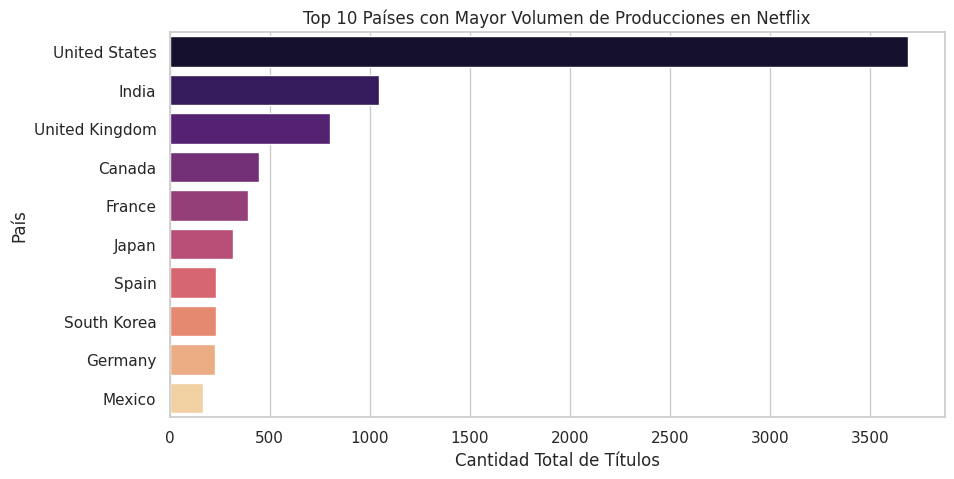

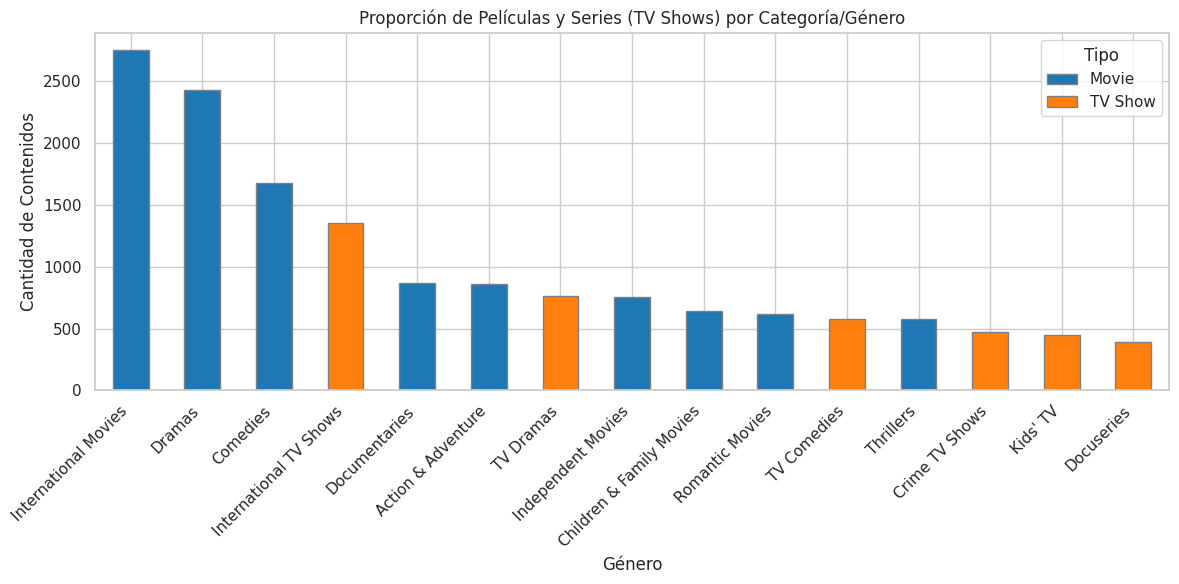

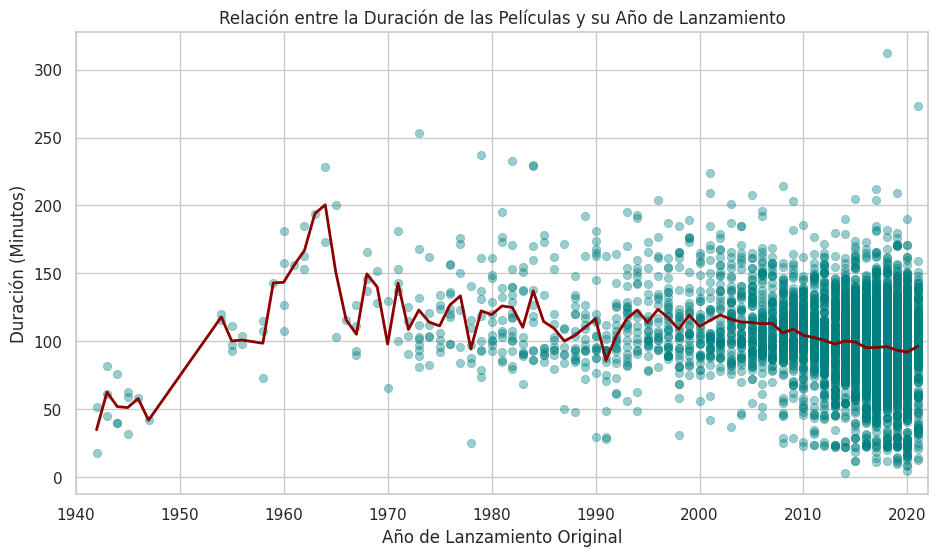

In [5]:
# FIXME
# --- Preparación de países ---
df_exploded_countries = df.copy()
df_exploded_countries['country_clean'] = df_exploded_countries['country'].str.split(', ')
df_exploded_countries = df_exploded_countries.explode('country_clean')

# 7. Top 10 países con más producciones
top_paises = df_exploded_countries['country_clean'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_paises.values, y=top_paises.index, palette='magma')
plt.title('Top 10 Países con Mayor Volumen de Producciones en Netflix')
plt.xlabel('Cantidad Total de Títulos')
plt.ylabel('País')
plt.show()


# 8. Películas vs Series según género (Barras Apiladas)
# Tomamos los 15 géneros globales más concurrentes
top_global_genres = df_exploded_genres['genre'].value_counts().head(15).index
df_genre_comparison = df_exploded_genres[df_exploded_genres['genre'].isin(top_global_genres)]

# Crear tabla de contingencia género vs tipo
genre_type_ct = pd.crosstab(df_genre_comparison['genre'], df_genre_comparison['type'])
# Ordenar de forma descendente por volumen total
genre_type_ct = genre_type_ct.loc[genre_type_ct.sum(axis=1).sort_values(ascending=False).index]

genre_type_ct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#1f77b4', '#ff7f0e'], edgecolor='grey')
plt.title('Proporción de Películas y Series (TV Shows) por Categoría/Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Contenidos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()


# 9. Relación entre duración y año de lanzamiento (Scatterplot)
df_movies_only = df[df['type'] == 'Movie'].dropna(subset=['duration_min'])

plt.figure(figsize=(11, 6))
sns.scatterplot(data=df_movies_only, x='release_year', y='duration_min', alpha=0.4, color='teal', edgecolor=None)
# Añadimos una línea de tendencia promedio móvil o aproximación para enriquecer el análisis visual
sns.regsub = sns.lineplot(data=df_movies_only, x='release_year', y='duration_min', color='darkred', errorbar=None, linewidth=2)

plt.title('Relación entre la Duración de las Películas y su Año de Lanzamiento')
plt.xlabel('Año de Lanzamiento Original')
plt.ylabel('Duración (Minutos)')
plt.xlim(1940, 2022)
plt.show()

## ⭐ Desafío Final

* Encuentra las combinaciones más frecuentes de **género + rating** y represéntalas en un **heatmap o gráfico de burbujas**.
* Pregunta guía: ¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?

# FIXME

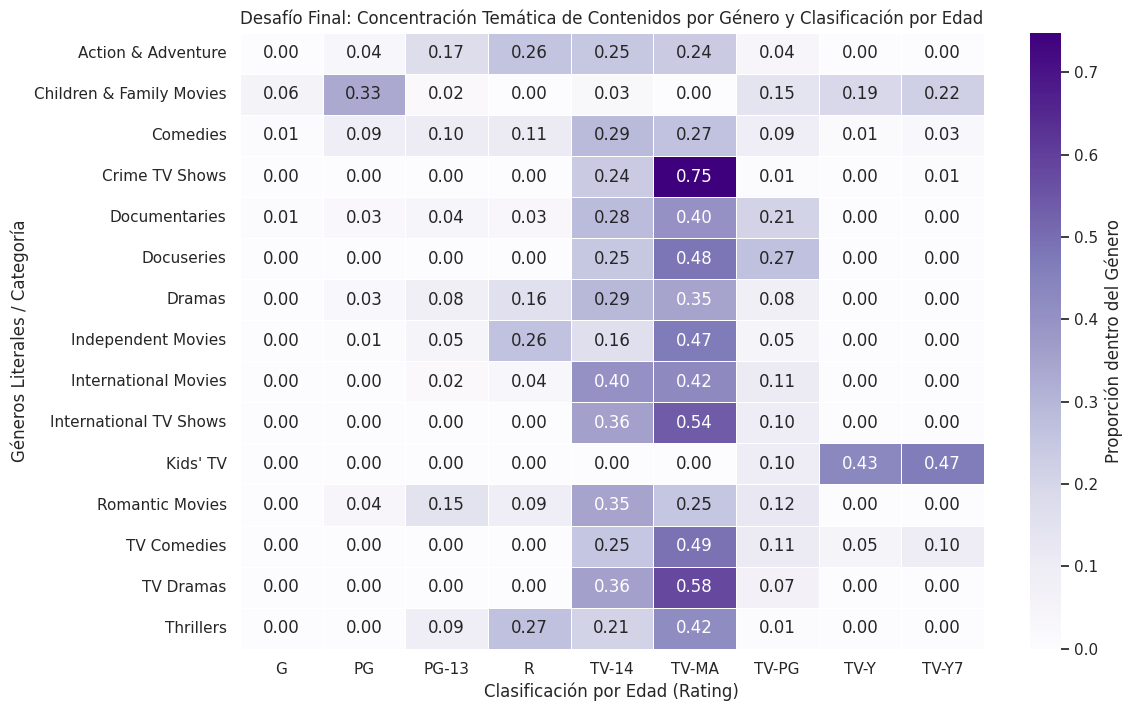

In [6]:
# Seleccionar los géneros y ratings más representativos para evitar ruido visual
ratings_interes = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'PG', 'TV-Y7', 'TV-Y', 'G']
df_desafio = df_exploded_genres[
    df_exploded_genres['genre'].isin(top_global_genres) &
    df_exploded_genres['rating'].isin(ratings_interes)
]

# Construir tabla cruzada de frecuencias
ct_desafio = pd.crosstab(df_desafio['genre'], df_desafio['rating'], normalize='index') # Normalizado por renglón para ver el foco de público por género

plt.figure(figsize=(12, 8))
sns.heatmap(ct_desafio, annot=True, fmt='.2f', cmap='Purples', linewidths=0.5, cbar_kws={'label': 'Proporción dentro del Género'})
plt.title('Desafío Final: Concentración Temática de Contenidos por Género y Clasificación por Edad')
plt.xlabel('Clasificación por Edad (Rating)')
plt.ylabel('Géneros Literales / Categoría')
plt.show()